# Proyek Klasifikasi Gambar:

## Import Semua Packages/Library yang Digunakan

In [1]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [2]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.20.0


## Data Preparation

### Data Loading

In [3]:
# ============================================================
# 2. DOWNLOAD DATASET KAGGLE
# ============================================================

!pip install -q kaggle

# Upload kaggle.json terlebih dahulu
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mostafaabla/garbage-classification

!unzip -q garbage-classification.zip -d /content/garbage_dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:01<00:00, 135MB/s]



In [4]:
# ============================================================
# 3. CEK DATASET
# ============================================================

DATASET_DIR = "/content/garbage_dataset"

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

    for file in files[:5]:
        print(f"{indent}  {file}")

garbage_dataset/
  garbage_classification/
    plastic/
    brown-glass/
    battery/
    green-glass/
    cardboard/
    paper/
    metal/
    shoes/
    trash/
    white-glass/
    clothes/
    biological/


In [5]:
# ============================================================
# 4. MENENTUKAN FOLDER DATASET
# ============================================================

# Jika struktur dataset memiliki folder garbage_classification
if os.path.exists("/content/garbage_dataset/garbage_classification"):
    DATASET_DIR = "/content/garbage_dataset/garbage_classification"
else:
    DATASET_DIR = "/content/garbage_dataset"

print("Dataset directory:", DATASET_DIR)

Dataset directory: /content/garbage_dataset/garbage_classification


In [6]:
# ============================================================
# 5. CEK JUMLAH GAMBAR
# ============================================================

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in sorted(os.listdir(DATASET_DIR)):
    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):
        count = 0

        for file in os.listdir(class_path):
            if file.lower().endswith(valid_extensions):
                count += 1

        class_counts[class_name] = count

print("Jumlah gambar per kelas:")

total_images = 0

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")
    total_images += count

print("\nTotal gambar:", total_images)
print("Jumlah kelas:", len(class_counts))

Jumlah gambar per kelas:
battery: 945
biological: 985
brown-glass: 607
cardboard: 891
clothes: 5325
green-glass: 629
metal: 769
paper: 1050
plastic: 865
shoes: 1977
trash: 697
white-glass: 775

Total gambar: 15515
Jumlah kelas: 12


In [7]:
# ============================================================
# 7. SPLIT DATASET
# ============================================================

SOURCE_DIR = DATASET_DIR
SPLIT_DIR = "/content/garbage_split"

# Hapus hasil split lama jika ada
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

os.makedirs(SPLIT_DIR)

train_dir = os.path.join(SPLIT_DIR, "train")
val_dir = os.path.join(SPLIT_DIR, "validation")
test_dir = os.path.join(SPLIT_DIR, "test")

os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

random.seed(42)

for class_name in sorted(os.listdir(SOURCE_DIR)):

    class_source = os.path.join(SOURCE_DIR, class_name)

    if not os.path.isdir(class_source):
        continue

    images = [
        f for f in os.listdir(class_source)
        if f.lower().endswith(valid_extensions)
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(total * 0.8)
    val_end = int(total * 0.9)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Buat folder kelas
    os.makedirs(os.path.join(train_dir, class_name))
    os.makedirs(os.path.join(val_dir, class_name))
    os.makedirs(os.path.join(test_dir, class_name))

    # Copy gambar
    for image_name in train_images:
        shutil.copy2(
            os.path.join(class_source, image_name),
            os.path.join(train_dir, class_name, image_name)
        )

    for image_name in val_images:
        shutil.copy2(
            os.path.join(class_source, image_name),
            os.path.join(val_dir, class_name, image_name)
        )

    for image_name in test_images:
        shutil.copy2(
            os.path.join(class_source, image_name),
            os.path.join(test_dir, class_name, image_name)
        )

print("Dataset berhasil dibagi.")

Dataset berhasil dibagi.


In [8]:
# ============================================================
# 8. CEK JUMLAH DATA SETIAP SPLIT
# ============================================================

def count_images(folder):

    total = 0

    for class_name in os.listdir(folder):

        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            total += len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_extensions)
            ])

    return total


train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

total_split = train_count + val_count + test_count

print("Train      :", train_count)
print("Validation :", val_count)
print("Test       :", test_count)
print("Total      :", total_split)

print("\nPersentase:")
print("Train      :", train_count / total_split * 100, "%")
print("Validation :", val_count / total_split * 100, "%")
print("Test       :", test_count / total_split * 100, "%")

Train      : 12409
Validation : 1550
Test       : 1556
Total      : 15515

Persentase:
Train      : 79.98066387367064 %
Validation : 9.990331936835322 %
Test       : 10.029004189494039 %


In [9]:
# ============================================================
# 9. LOAD DATASET
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Number of classes:", NUM_CLASSES)

Found 12409 files belonging to 12 classes.
Found 1550 files belonging to 12 classes.
Found 1556 files belonging to 12 classes.
Class names: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']
Number of classes: 12


In [10]:
# ============================================================
# 10. OPTIMASI DATA PIPELINE
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

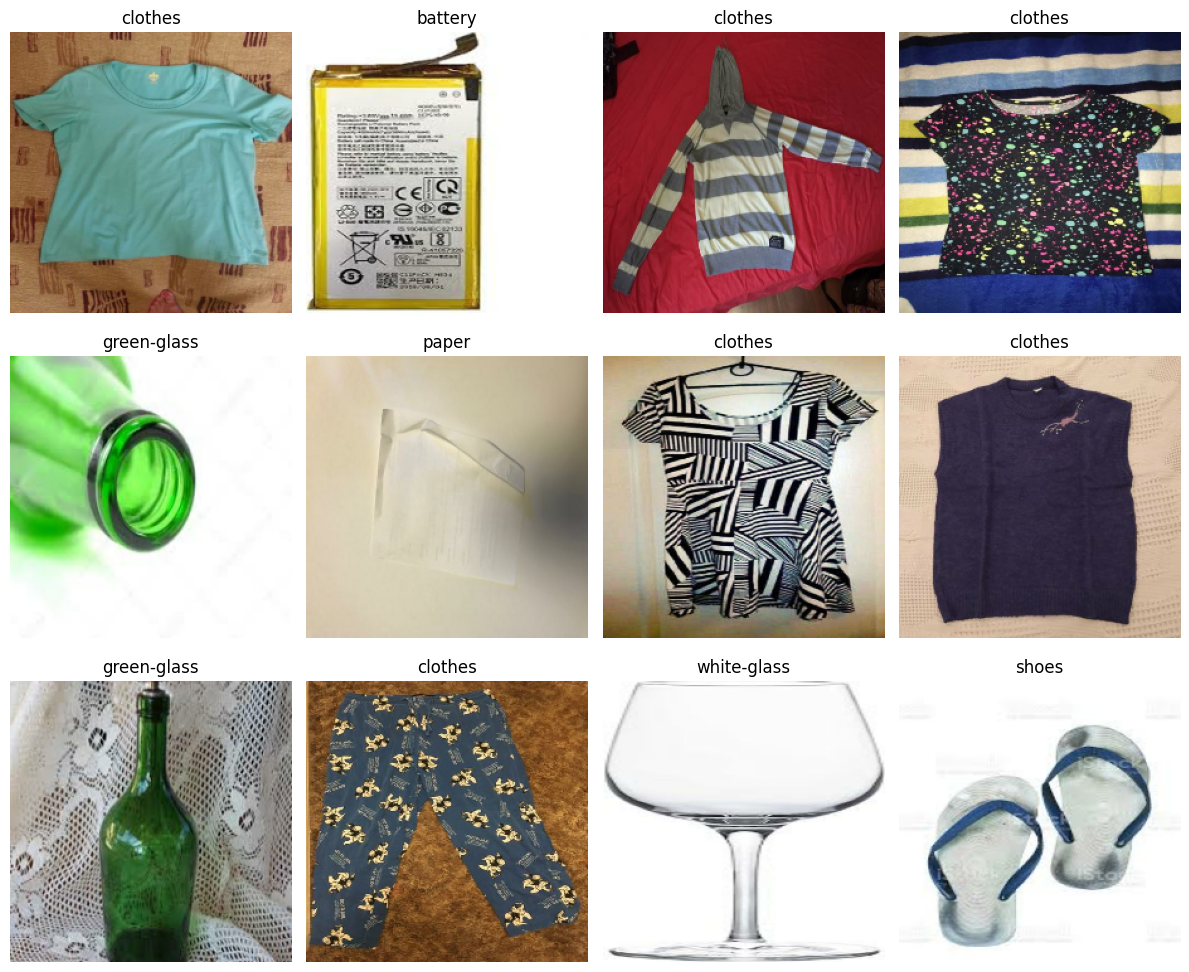

In [11]:
# ============================================================
# 11. VISUALISASI CONTOH DATASET
# ============================================================

plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):

    for i in range(min(12, len(images))):

        ax = plt.subplot(3, 4, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 12. DATA AUGMENTATION
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [ ]:
# ============================================================
# 13. MEMBUAT MODEL CNN
# ============================================================

model = Sequential([

    # Input
    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Normalisasi pixel
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # CNN Block 4
    layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D((2, 2)),

    # Regularization
    layers.Dropout(0.3),

    # Classification
    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    # Output
    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,236,812 (50.49 MB)

 Trainable params: 13,236,812 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 14. COMPILE MODEL
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
# ============================================================
# 15. CALLBACK
# ============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr
]

In [ ]:
# ============================================================
# 16. TRAINING
# ============================================================

EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 49s 103ms/step - accuracy: 0.4712 - loss: 1.6288 - val_accuracy: 0.5619 - val_loss: 1.2665 - learning_rate: 0.0010
Epoch 2/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 39s 102ms/step - accuracy: 0.5825 - loss: 1.2420 - val_accuracy: 0.6594 - val_loss: 1.0566 - learning_rate: 0.0010
Epoch 3/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.6312 - loss: 1.1186 - val_accuracy: 0.6768 - val_loss: 0.9959 - learning_rate: 0.0010
Epoch 4/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.6623 - loss: 1.0386 - val_accuracy: 0.6852 - val_loss: 0.9578 - learning_rate: 0.0010
Epoch 5/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.6779 - loss: 0.9816 - val_accuracy: 0.7161 - val_loss: 0.8517 - learning_rate: 0.0010
Epoch 6/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 39s 101ms/step - accuracy: 0.6979 - loss: 0.9223 - val_accuracy: 0.7161 - val_loss: 0.8205 - learning_rate: 0.0010
Epoch 7/50
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.72

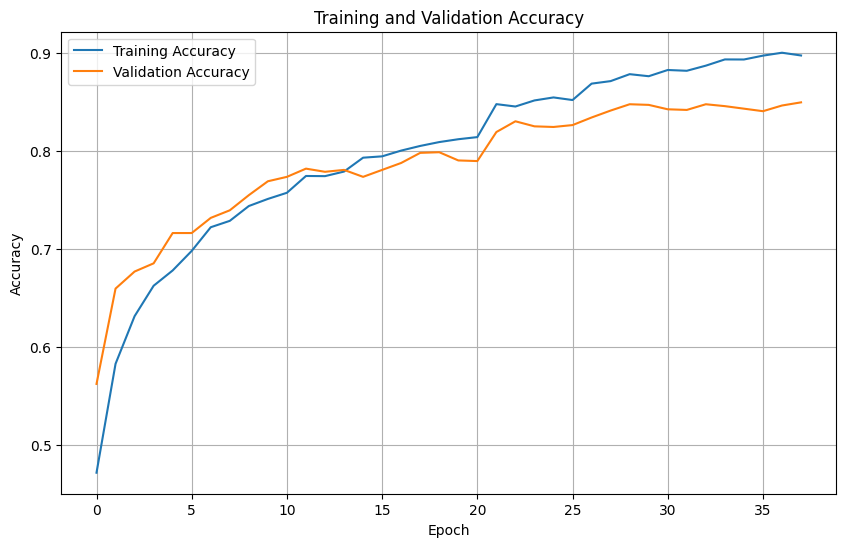

In [ ]:
# ============================================================
# 17. PLOT ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

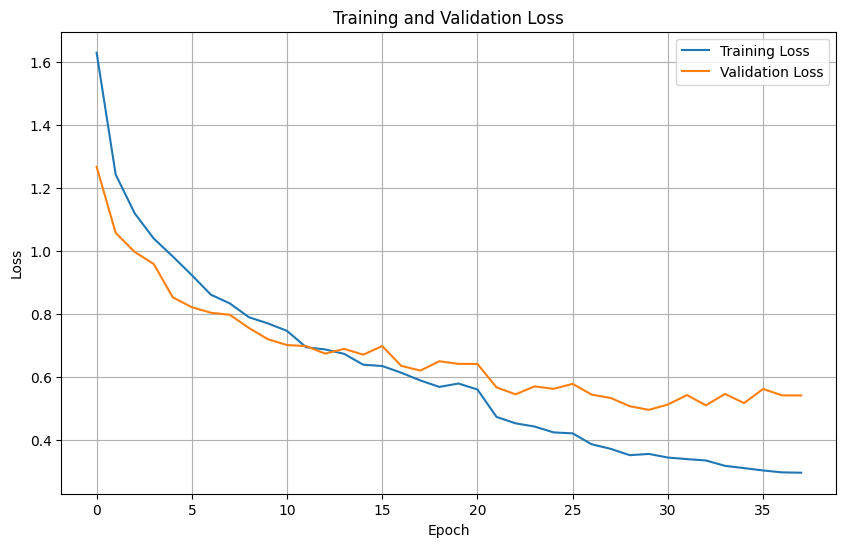

In [ ]:
# ============================================================
# 18. PLOT LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# 19. EVALUASI TRAINING
# ============================================================

train_loss, train_accuracy = model.evaluate(
    train_ds,
    verbose=1
)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Training Loss    : {train_loss:.4f}")

388/388 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.9388 - loss: 0.1883
Training Accuracy: 93.88%
Training Loss    : 0.1883


In [ ]:
# ============================================================
# 20. EVALUASI TEST
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"Testing Loss    : {test_loss:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8458 - loss: 0.5334
Testing Accuracy: 84.58%
Testing Loss    : 0.5334


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ============================================================
# 1. LOAD MOBILE NET V2
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze terlebih dahulu
base_model.trainable = False

# ============================================================
# 2. MODEL SEQUENTIAL
# ============================================================

model = Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),

    # MobileNetV2 preprocessing
    layers.Rescaling(
        scale=1./127.5,
        offset=-1
    ),

    # Transfer learning
    base_model,

    # Conv2D -> memenuhi kriteria
    layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    # Pooling -> memenuhi kriteria
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 128)      │     1,474,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,751,244 (14.31 MB)

 Trainable params: 1,493,004 (5.70 MB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    mode="max",
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 42s 80ms/step - accuracy: 0.8566 - loss: 0.4848 - val_accuracy: 0.9303 - val_loss: 0.2266 - learning_rate: 0.0010
Epoch 2/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 31s 71ms/step - accuracy: 0.9014 - loss: 0.3052 - val_accuracy: 0.9271 - val_loss: 0.2302 - learning_rate: 0.0010
Epoch 3/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.9223 - loss: 0.2524 - val_accuracy: 0.9413 - val_loss: 0.1953 - learning_rate: 0.0010
Epoch 4/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.9283 - loss: 0.2226 - val_accuracy: 0.9387 - val_loss: 0.2033 - learning_rate: 0.0010
Epoch 5/30
388/388 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.9360 - loss: 0.2010 - val_accuracy: 0.9335 - val_loss: 0.2194 - learning_rate: 0.0010
Epoch 6/30
387/388 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9402 - loss: 0.1831
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
388/388 ━━━━━━━━━━━━━━━━━━━━ 31s 79ms/step - accuracy: 0.9421 - los

In [16]:
# ============================================================
# 19. EVALUASI TRAINING
# ============================================================

train_loss, train_accuracy = model.evaluate(
    train_ds,
    verbose=1
)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Training Loss    : {train_loss:.4f}")

388/388 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - accuracy: 0.9929 - loss: 0.0217
Training Accuracy: 99.29%
Training Loss    : 0.0217


In [17]:
# ============================================================
# 20. EVALUASI TEST
# ============================================================

test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"Testing Loss    : {test_loss:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.9544 - loss: 0.1802
Testing Accuracy: 95.44%
Testing Loss    : 0.1802


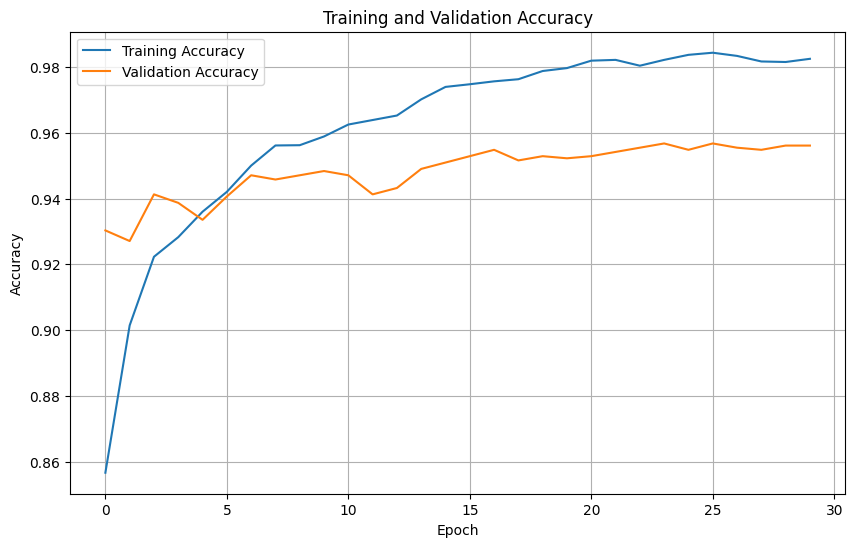

In [18]:
# ============================================================
# 17. PLOT ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

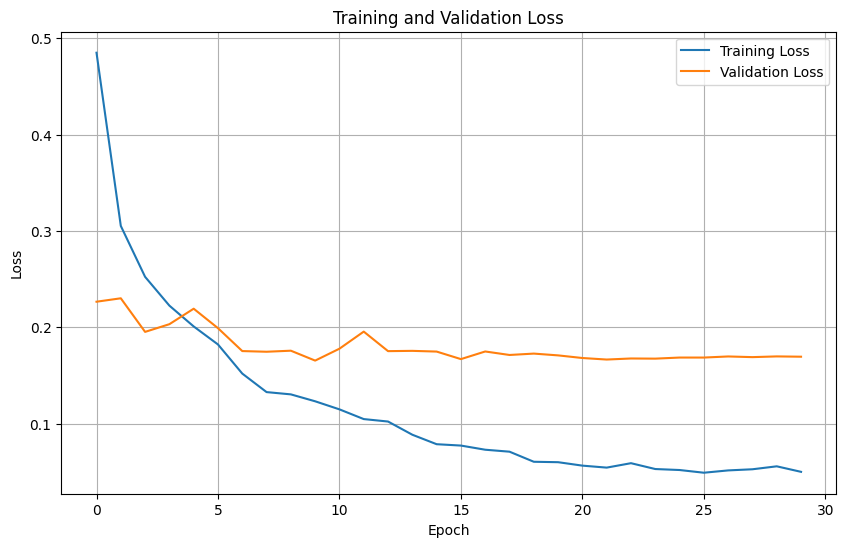

In [19]:
# ============================================================
# 18. PLOT LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Konversi Model

**Menyimpan Model dalam Format SavedModel**

In [20]:
model.save("model.h5")

In [38]:
inference_input = tf.keras.Input(shape=(224, 224, 3))
x = inference_input

# Start from the Rescaling layer (index 5 in the original model)
# and include all subsequent layers with their trained weights
for layer in model.layers[5:]:
    x = layer(x)

inference_model = tf.keras.Model(inputs=inference_input, outputs=x)
inference_model.export('my_model_savedmodel')

Saved artifact at 'my_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_189')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  134625533776848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533779920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533780112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533779344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533778576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533777232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533780688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533781648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533781264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625533778960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134625

**Simpan ke Format TensorFlow.js (TFJS)**

In [31]:
# Install tensorflowjs
!pip install tensorflowjs

# Convert my_model_savedmodel to tensorflow.js format
!tensorflowjs_converter --input_format=tf_saved_model my_model_savedmodel tfjs_model

2026-08-16 02:17:22.986349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786846643.007654   11608 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786846643.014326   11608 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786846643.030185   11608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786846643.030236   11608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786846643.030244   11608 computation_placer.cc:177] computation placer alr

In [39]:
# Convert my_model_savedmodel to tensorflow.js format
!tensorflowjs_converter --input_format=tf_saved_model my_model_savedmodel tfjs_model

2026-08-16 02:22:39.297594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786846959.321450   13097 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786846959.328598   13097 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786846959.346733   13097 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786846959.346787   13097 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786846959.346794   13097 computation_placer.cc:177] computation placer alr

In [25]:
# ============================================================
# ZIP SAVEDMODEL
# ============================================================

import shutil
from google.colab import files

save_path = "tfjs_model"

# Buat file ZIP dari folder mymodel
zip_path = shutil.make_archive(
    "tfjs",
    "zip",
    save_path
)

print("ZIP berhasil dibuat:")
print(zip_path)

# Download ZIP
files.download(zip_path)

ZIP berhasil dibuat:
/content/tfjs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
save_path = 'mymodel/'

# Create an inference-only model by excluding data augmentation layers
inference_input = tf.keras.Input(shape=(224, 224, 3))
x = inference_input

# Start from the Rescaling layer (index 5 in the original model)
# and include all subsequent layers with their trained weights
for layer in model.layers[5:]:
    x = layer(x)

inference_model = tf.keras.Model(inputs=inference_input, outputs=x)

# Save the inference-only model
tf.saved_model.save(inference_model, save_path)

In [27]:
# ============================================================
# ZIP SAVEDMODEL
# ============================================================

import shutil
from google.colab import files

save_path = "mymodel"

# Buat file ZIP dari folder mymodel
zip_path = shutil.make_archive(
    "mymodel",
    "zip",
    save_path
)

print("ZIP berhasil dibuat:")
print(zip_path)

# Download ZIP
files.download(zip_path)

ZIP berhasil dibuat:
/content/mymodel.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Simpan ke Format TensorFlow Lite (TF-Lite)**

In [28]:
import pathlib

# Menyimpan model dalam format SavedModel
export_dir = 'saved_model/'

# Create an inference-only model by excluding data augmentation layers
inference_input = tf.keras.Input(shape=(224, 224, 3))
x = inference_input

# Start from the Rescaling layer (index 5 in the original model)
# and include all subsequent layers with their trained weights
# This assumes the model structure from cell 'om51R-YHpNV0' where
# layers 1-4 are data augmentation and layer 5 is Rescaling.
for layer in model.layers[5:]:
    x = layer(x)

inference_model_for_export = tf.keras.Model(inputs=inference_input, outputs=x)

tf.saved_model.save(inference_model_for_export, export_dir)

# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)

210196

In [29]:
 pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==25.1.0
aiohappyeyeballs==2.7.1
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.14.2
anywidget==0.9.21
apsw==3.53.3.1
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.2
astropy-iers-data==0.2026.7.13.0.54.2
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.9.1
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.8.0
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.6.17
cffi==2.1.0
charde